# 19 · `spaghetti`

`Map.spaghetti` overlays each member of a `DatasetCollection` as line contours on one axes — the classic ensemble 'spaghetti' map.

**Setup** — inline plots, the DEM path, and an 8-member ensemble built by adding a random smooth tilt to the DEM so the members' isolines diverge.

In [1]:
%matplotlib inline
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "examples" / "data" / "LisbonElevation.tif").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DEM = str(ROOT / "examples" / "data" / "LisbonElevation.tif")
from pyramids.dataset import Dataset, GeoReference
from digitalearth.scene import Map
import numpy as np
from pyramids.dataset.collection import DatasetCollection
ds = Dataset.read_file(DEM)
z = np.nan_to_num(ds.read_array(band=0).astype("float32"))
rows, cols = z.shape
yy, xx = np.mgrid[0:rows, 0:cols] / max(rows, cols)
rng = np.random.default_rng(0)
members = []
for _ in range(8):
    ax_, ay_ = rng.uniform(-60, 60, 2)            # random smooth tilt across the scene
    arr = (z + ax_ * xx + ay_ * yy).astype("float32")
    members.append(Dataset.from_array(arr=arr, geo_ref=GeoReference(geo=ds.geotransform, epsg=ds.epsg)))
dc = DatasetCollection(members[0], len(members), datasets=members)

Overlay all 8 members' contours (a few levels each). Because every member has a different tilt, the isolines spread out into spaghetti.

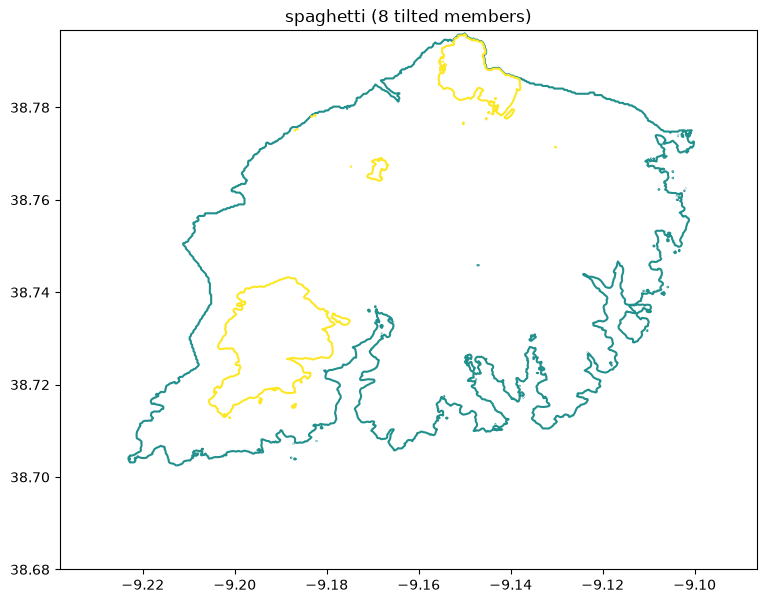

In [2]:
m = Map(crs=ds.epsg, figsize=(9, 7))
m.spaghetti(dc, levels=4)
m.set_title('spaghetti (8 tilted members)')
m.fig;